In [1]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv(r"C:\Users\Daniel\Downloads\Python pract\Linear Regression\USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
df.shape

(5000, 7)

In [7]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [20]:
numeric_col=df.select_dtypes(include=['number']).columns
numeric_col

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

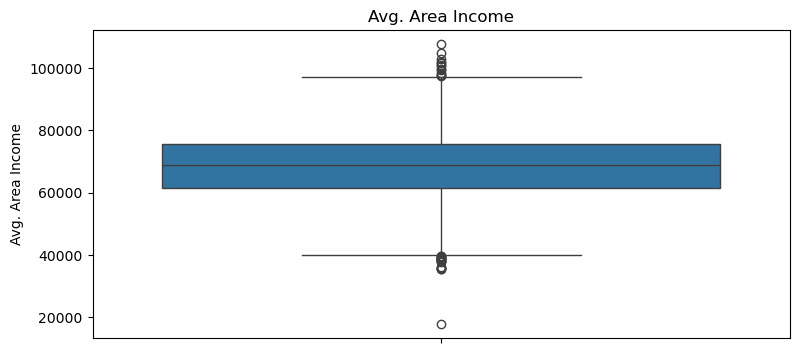

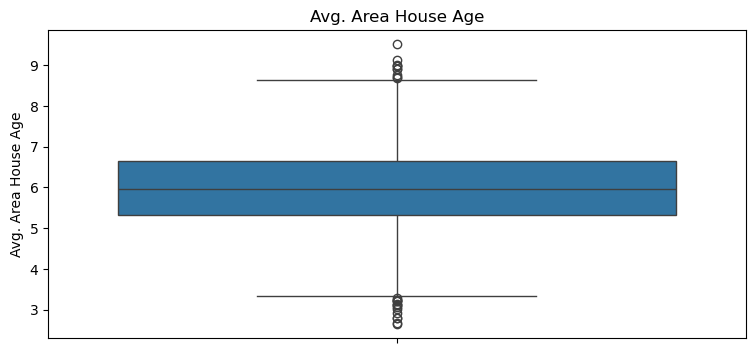

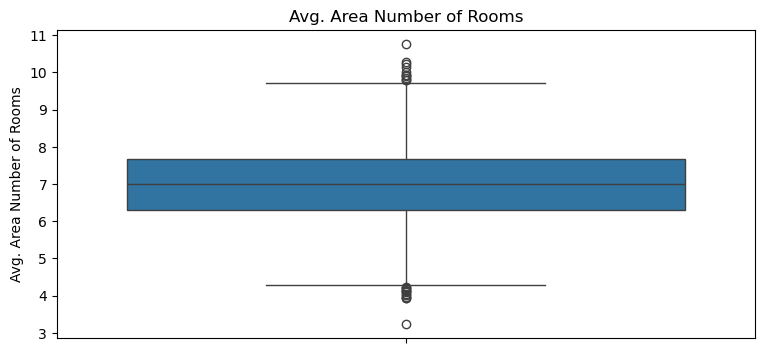

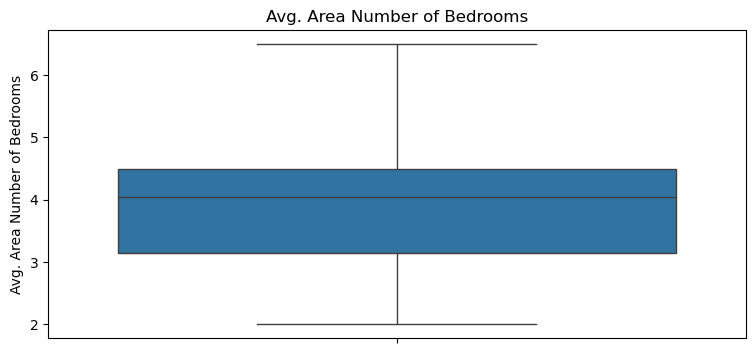

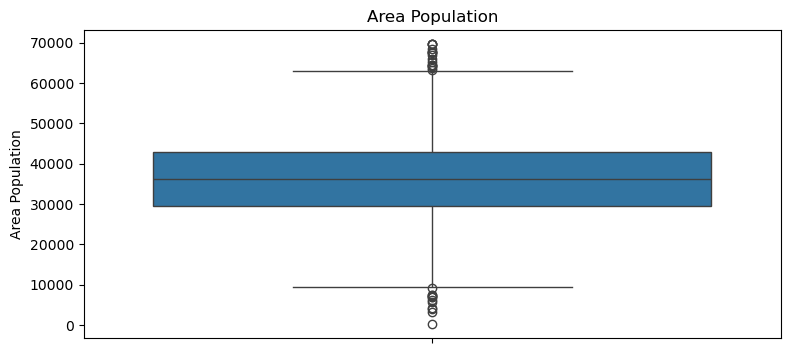

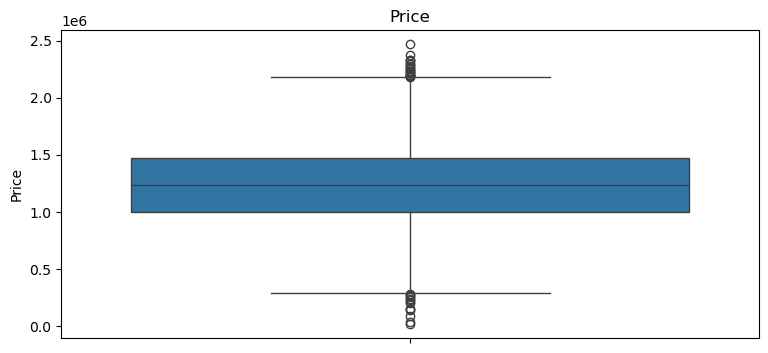

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
for c in numeric_col:
    plt.figure(figsize=(9,4))
    sns.boxplot(y=c,data=df)
    plt.title(c)
    plt.show()

In [23]:
#inter quartile range
q1=df[numeric_col].quantile(0.25)
q1.head()

Avg. Area Income                61480.562388
Avg. Area House Age                 5.322283
Avg. Area Number of Rooms           6.299250
Avg. Area Number of Bedrooms        3.140000
Area Population                 29403.928702
Name: 0.25, dtype: float64

In [24]:
q3=df[numeric_col].quantile(0.75)
q3.head()

Avg. Area Income                75783.338666
Avg. Area House Age                 6.650808
Avg. Area Number of Rooms           7.665871
Avg. Area Number of Bedrooms        4.490000
Area Population                 42861.290769
Name: 0.75, dtype: float64

In [25]:
IQR=q3-q1
IQR.head()

Avg. Area Income                14302.776278
Avg. Area House Age                 1.328525
Avg. Area Number of Rooms           1.366621
Avg. Area Number of Bedrooms        1.350000
Area Population                 13457.362067
dtype: float64

In [26]:
pos_outlier=q3+1.5*IQR
neg_outlier=q1-1.5*IQR

In [27]:
df=df[~((df[numeric_col]<(q1-1.5*IQR)) | (df[numeric_col]>(q3+1.5*IQR))).any(axis=1)]

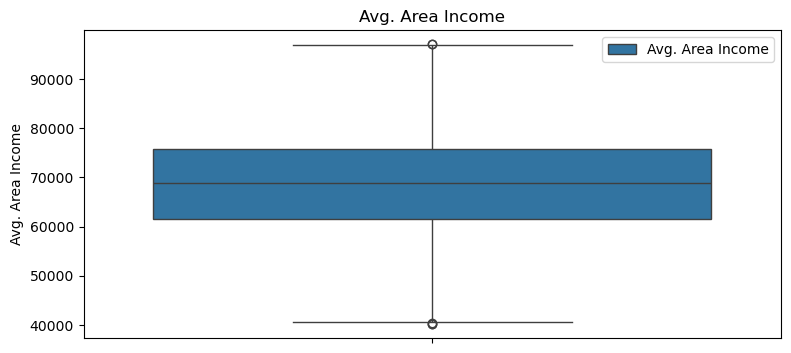

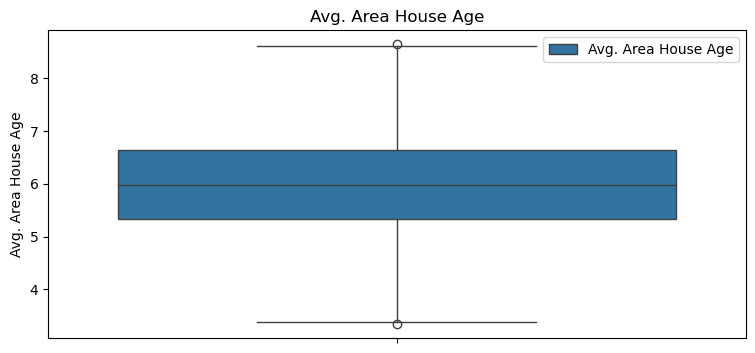

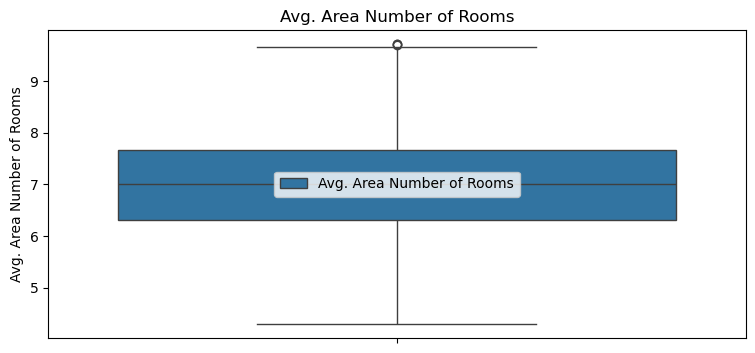

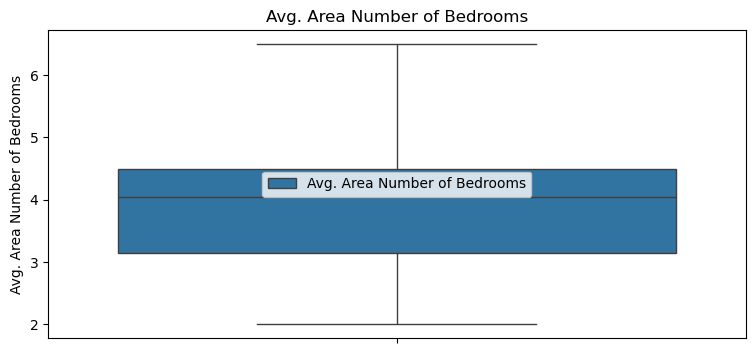

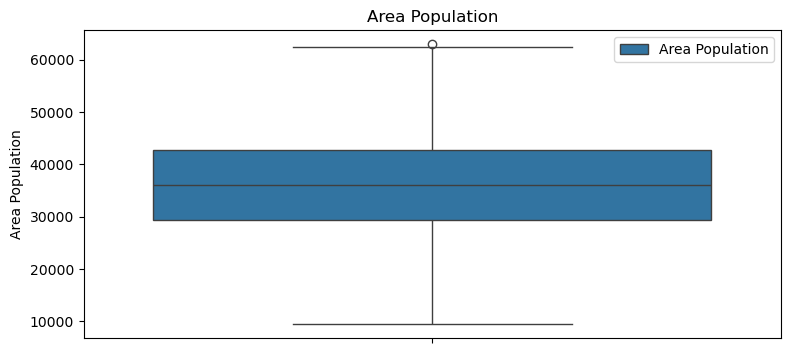

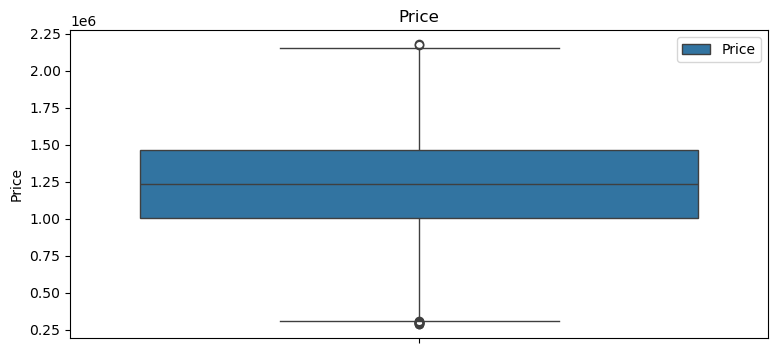

In [30]:
for c in numeric_col:
    plt.figure(figsize=(9,4))
    sns.boxplot(y=c,label=c,data=df)
    plt.title(c)
    plt.show()

In [31]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [34]:
df=df.drop('Address',axis=1)

In [35]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


<Axes: xlabel='Price', ylabel='Count'>

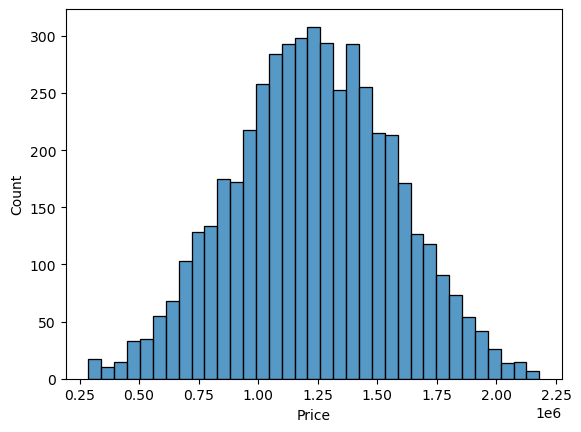

In [43]:
sns.histplot(df['Price'],edgecolor='black')

In [44]:
df.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.021102,-0.021113,0.012875,-0.014097,0.632031
Avg. Area House Age,-0.021102,1.000000,-0.016919,0.001177,-0.024151,0.441675
Avg. Area Number of Rooms,-0.021113,-0.016919,1.000000,0.466596,-0.000244,0.329630
Avg. Area Number of Bedrooms,0.012875,0.001177,0.466596,1.000000,-0.023172,0.168606
Area Population,-0.014097,-0.024151,-0.000244,-0.023172,1.000000,0.406027
Price,0.632031,0.441675,0.329630,0.168606,0.406027,1.000000


<Axes: >

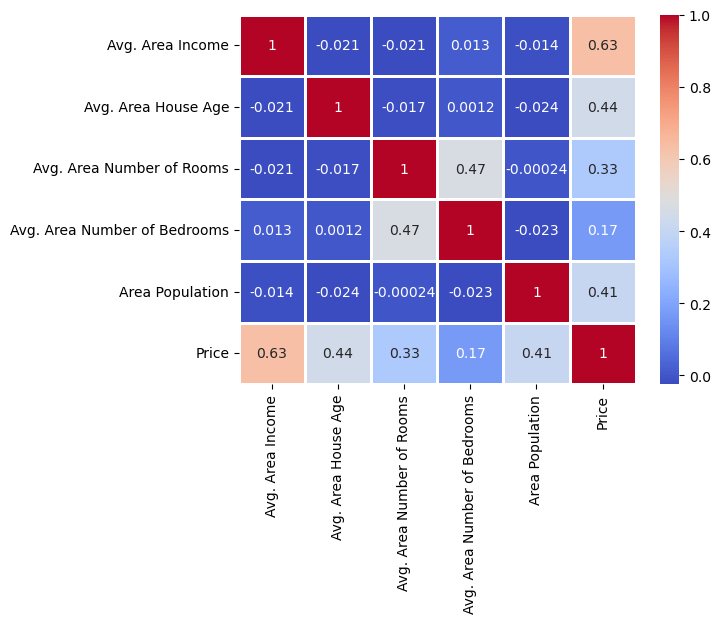

In [48]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',linewidths=1)

In [49]:
x=df.drop('Price',axis=1)
y=df['Price']

In [50]:
x

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [51]:
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 4865, dtype: float64

In [62]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [63]:
x_scale=scaler.fit_transform(x)

In [64]:
x_scale

array([[ 1.06071779, -0.30363229,  0.02290907,  0.0859644 , -1.35240284],
       [ 1.03191461,  0.02775903, -0.25978767, -0.72371729,  0.4207993 ],
       [-0.7110857 , -0.11411114,  1.5498338 ,  0.92803335,  0.07927052],
       ...,
       [-0.50694938,  1.31970959, -2.2154799 , -1.50101171, -0.29599705],
       [-0.05953013, -0.45737203,  0.14574608,  1.17903467,  0.67532313],
       [-0.30123371,  0.0167887 , -0.1973158 ,  0.06977076,  1.07753698]])

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,test_size=0.2,random_state=80)

In [66]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [67]:
model.fit(x_train,y_train)

LinearRegression()

In [69]:
y_pred_test=model.predict(x_test)

In [70]:
y_pred_train=model.predict(x_train)

In [72]:
from sklearn.metrics import r2_score#,mean_square_error,mean_absolute_error,root_mean_square_erro

In [73]:
test=r2_score(y_test,y_pred_test)
test

0.9147357708819565

In [74]:
train=r2_score(y_train,y_pred_train)
train

0.9109909775432479

In [91]:
from sklearn.linear_model import Lasso,Ridge,LassoCV
lasso=Lasso()
ridge=Ridge()

In [92]:
lassocv=LassoCV(alphas=[0.1,0.3,0.5,1,4,8,10],cv=1000)
lassocv.fit(x_train,y_train)
print('best',lassocv.alpha_)

best 4.0


In [80]:
lasso.fit(x_train,y_train)
ls_train=lasso.predict(x_train)
ls_test=lasso.predict(x_test)
ls_tr_score=r2_score(y_train,ls_train)
ls_tt_score=r2_score(y_test,ls_test)
print('train:',ls_tr_score)
print('test:',ls_tt_score)

train: 0.9109909775085323
test: 0.9147356860503097


In [82]:
ridge.fit(x_train,y_train)
r_train=ridge.predict(x_train)
r_test=ridge.predict(x_test)
rr_train=r2_score(y_train,r_train)
rr_test=r2_score(y_test,r_test)
print('train:',rr_train)
print('test:',rr_test)

train: 0.910990907517095
test: 0.9147341189015513


In [87]:
#VIF(variance inflation factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif


In [89]:
vif_var=pd.DataFrame()
variable=x_scale
vif_var['variance_inflation_factor']=[vif(variable,i) for i in range(variable.shape[1])]
vif_var['features']=x.columns
vif_var

,variance_inflation_factor,features
0,1.001776,Avg. Area Income
1,1.001451,Avg. Area House Age
2,1.280194,Avg. Area Number of Rooms
3,1.280126,Avg. Area Number of Bedrooms
4,1.001448,Area Population


In [95]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error

In [97]:
mse=mean_squared_error(y_train,ls_train)
print('mse:',mse)
mae=mean_absolute_error(y_train,ls_train)
print('mae',mae)
rmse=root_mean_squared_error(y_train,ls_train)
print('rmse',rmse)

mse: 10119256805.869305
mae 80676.6448273316
rmse 100594.51677834784
